# 02_dataset.ipynb — PatchTST 用データ準備

このノートブックでやること:
- 第3弾（weather-lstm）の処理済みデータを再利用する
- PatchTST が要求する入力 shape に変換する
- LSTM との shape の違いを確認する

**LSTMとの違いはここだけ:**
```
LSTM    : past_values=(B, 30, 1)  /  y=(B, 7)
PatchTST: past_values=(B, 30, 1)  /  y=(B, 7, 1)  ← 最後に次元が1つ増える
```

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
from pathlib import Path
import numpy as np
import pandas as pd
import pickle
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler

# 第3弾と同じパス（処理済みデータを再利用）
DATA_LSTM_PROC = Path('/content/drive/MyDrive/project/weather-lstm/processed')
DATA_LSTM_RAW  = Path('/content/drive/MyDrive/project/weather-lstm/raw')

# 第4弾の保存先
DATA_PROC = Path('/content/drive/MyDrive/project/weather-patchtst/processed')
DATA_PROC.mkdir(parents=True, exist_ok=True)

SEQ_LEN   = 30
PRED_LEN  = 7
BATCH_SIZE = 32

## 1. 第3弾の処理済みデータを再利用する

前処理（MinMaxScaler・スライディングウィンドウ・分割）は第3弾と全く同じ。  
すでに保存済みの `.npy` ファイルをそのまま読み込みます。

In [4]:
lstm_files = ['X_train.npy', 'y_train.npy', 'X_val.npy', 'y_val.npy', 'X_test.npy', 'y_test.npy', 'scaler.pkl']
missing = [f for f in lstm_files if not (DATA_LSTM_PROC / f).exists()]

if missing:
    print(f'⚠️ 以下のファイルが見つかりません: {missing}')
    print('weather-lstm の 02_preprocess.ipynb を先に実行してください。')
else:
    print('第3弾の処理済みデータが見つかりました ✅')
    for f in lstm_files:
        p = DATA_LSTM_PROC / f
        size = p.stat().st_size / 1024
        print(f'  {f:20s}  {size:.1f} KB')

第3弾の処理済みデータが見つかりました ✅
  X_train.npy           593.3 KB
  y_train.npy           138.5 KB
  X_val.npy             127.4 KB
  y_val.npy             29.8 KB
  X_test.npy            127.4 KB
  y_test.npy            29.8 KB
  scaler.pkl            0.5 KB


In [5]:
X_train = np.load(DATA_LSTM_PROC / 'X_train.npy')
y_train = np.load(DATA_LSTM_PROC / 'y_train.npy')
X_val   = np.load(DATA_LSTM_PROC / 'X_val.npy')
y_val   = np.load(DATA_LSTM_PROC / 'y_val.npy')
X_test  = np.load(DATA_LSTM_PROC / 'X_test.npy')
y_test  = np.load(DATA_LSTM_PROC / 'y_test.npy')

with open(DATA_LSTM_PROC / 'scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

print('LSTM 用データの shape（第3弾と同じ）:')
print(f'  X_train: {X_train.shape}   # (サンプル数, SEQ_LEN)')
print(f'  y_train: {y_train.shape}   # (サンプル数, PRED_LEN)')
print(f'  X_test:  {X_test.shape}')
print(f'  y_test:  {y_test.shape}')

LSTM 用データの shape（第3弾と同じ）:
  X_train: (2531, 30)   # (サンプル数, SEQ_LEN)
  y_train: (2531, 7)   # (サンプル数, PRED_LEN)
  X_test:  (543, 30)
  y_test:  (543, 7)


## 2. PatchTST 用 Dataset を作る

LSTMとの違いは **`y` の shape だけ** です。

```
LSTM Dataset:
  X: (B, 30, 1)  ← past_values
  y: (B, 7)      ← pred_len のみ

PatchTST Dataset:
  X: (B, 30, 1)  ← past_values（同じ）
  y: (B, 7, 1)   ← pred_len × num_channels（チャネル次元が増える）
```

なぜ `y` の shape が違うのか？
PatchTST は複数変数（multivariate）を前提とした設計のため、  
出力が常に `(batch, pred_len, num_channels)` の 3 次元になっています。  
今回は 1 変数なので `num_channels=1` ですが、次元は省略できません。

In [6]:
class WeatherDatasetPatchTST(Dataset):
    """PatchTST 用 Dataset。LSTMと違うのは y の shape のみ。"""
    def __init__(self, X, y):
        # X: (N, seq_len) → (N, seq_len, 1)
        self.X = torch.tensor(X, dtype=torch.float32).unsqueeze(-1)
        # y: (N, pred_len) → (N, pred_len, 1)  ← ここが LSTM と違う
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(-1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


train_dataset = WeatherDatasetPatchTST(X_train, y_train)
val_dataset   = WeatherDatasetPatchTST(X_val,   y_val)
test_dataset  = WeatherDatasetPatchTST(X_test,  y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

X_batch, y_batch = next(iter(train_loader))
print('PatchTST 用バッチ shape:')
print(f'  X_batch: {X_batch.shape}   # (batch, seq_len=30, channels=1)')
print(f'  y_batch: {y_batch.shape}   # (batch, pred_len=7, channels=1)')

PatchTST 用バッチ shape:
  X_batch: torch.Size([32, 30, 1])   # (batch, seq_len=30, channels=1)
  y_batch: torch.Size([32, 7, 1])   # (batch, pred_len=7, channels=1)


## 3. PatchTST へ渡す方法の確認

LSTMとの呼び出し方の違いを確認しておきます。

In [7]:
# モデルに渡すときの書き方の違い
print('=== LSTM の場合 ===')
print('  output = model(X_batch)              # テンソルをそのまま渡す')
print('  output.shape → (B, 7)')
print()
print('=== PatchTST の場合 ===')
print('  output = model(past_values=X_batch)  # キーワード引数で渡す')
print('  output.prediction_outputs.shape → (B, 7, 1)')
print()
print('損失計算時のsqueeze:')
print('  pred = output.prediction_outputs.squeeze(-1)  # (B, 7, 1) → (B, 7)')
print('  loss = criterion(pred, y_batch.squeeze(-1))')

=== LSTM の場合 ===
  output = model(X_batch)              # テンソルをそのまま渡す
  output.shape → (B, 7)

=== PatchTST の場合 ===
  output = model(past_values=X_batch)  # キーワード引数で渡す
  output.prediction_outputs.shape → (B, 7, 1)

損失計算時のsqueeze:
  pred = output.prediction_outputs.squeeze(-1)  # (B, 7, 1) → (B, 7)
  loss = criterion(pred, y_batch.squeeze(-1))


In [8]:
# 実際に PatchTST に渡して shape を確認
from transformers import PatchTSTConfig, PatchTSTForPrediction

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

config = PatchTSTConfig(
    num_input_channels=1,
    context_length=SEQ_LEN,
    prediction_length=PRED_LEN,
    patch_length=6,
    stride=1,
    d_model=128,
    num_attention_heads=4,
    num_hidden_layers=3,
    dropout=0.2,
    head_dropout=0.2,
)
model = PatchTSTForPrediction(config).to(device)

model.eval()
with torch.no_grad():
    output = model(past_values=X_batch.to(device))

pred = output.prediction_outputs  # (B, 7, 1)
print(f'past_values 入力 shape : {X_batch.shape}')
print(f'prediction_outputs shape: {pred.shape}')
print(f'squeeze(-1) 後          : {pred.squeeze(-1).shape}  ← 損失計算に使う')

past_values 入力 shape : torch.Size([32, 30, 1])
prediction_outputs shape: torch.Size([32, 7, 1])
squeeze(-1) 後          : torch.Size([32, 7])  ← 損失計算に使う


## 4. データ分布を目視確認

In [10]:
!pip install -q japanize-matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 115.0 MB/s eta 0:00:0000:01
  Preparing metadata (setup.py) ... done


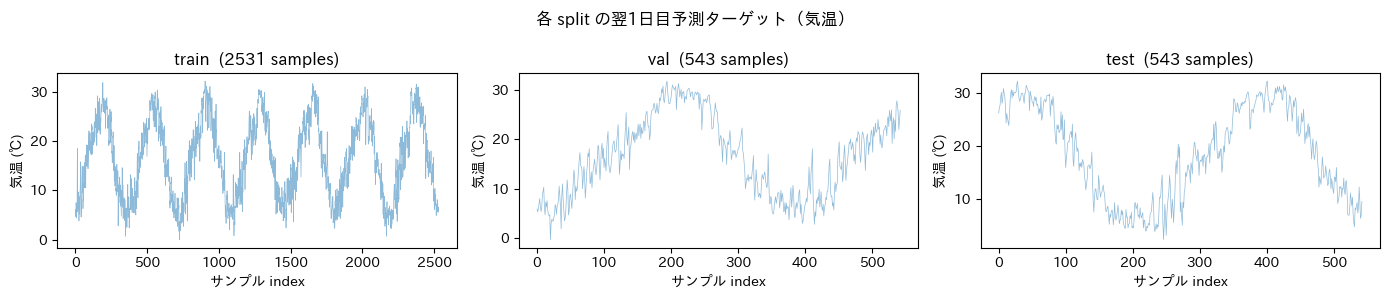

train 気温範囲: 0.0〜32.2℃


In [15]:
import matplotlib.pyplot as plt
import japanize_matplotlib

fig, axes = plt.subplots(1, 3, figsize=(14, 3))
splits = [('train', y_train), ('val', y_val), ('test', y_test)]

for ax, (name, y) in zip(axes, splits):
    # 逆変換して℃に戻す
    y_orig = scaler.inverse_transform(y.reshape(-1, 1)).reshape(y.shape)
    ax.plot(y_orig[:, 0], alpha=0.5, linewidth=0.5)
    ax.set_title(f'{name}  ({len(y)} samples)')
    ax.set_ylabel('気温 (℃)')
    ax.set_xlabel('サンプル index')

plt.suptitle('各 split の翌1日目予測ターゲット（気温）')
plt.tight_layout()
plt.show()

print(f'train 気温範囲: {scaler.inverse_transform(y_train.reshape(-1,1)).min():.1f}〜{scaler.inverse_transform(y_train.reshape(-1,1)).max():.1f}℃')

## 確認チェックリスト

- [ ] 第3弾の `.npy` ファイルが見つかった
- [ ] `X_batch: torch.Size([32, 30, 1])` になった
- [ ] `y_batch: torch.Size([32, 7, 1])` になった（LSTMと違う点）
- [ ] `prediction_outputs` の shape が `(32, 7, 1)` になった

すべてOKなら `03_train.ipynb` へ進んでください。